<a href="https://colab.research.google.com/github/Aldritch001/cropguard-ai/blob/main/03_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CropGuard AI - Model Training
Author: Absolon

Training a crop disease classifier using transfer learning on top of EfficientNetB0. Instead of training a network from scratch, which would need a lot more data and compute than I have access to, I'm starting from a model already trained on ImageNet and fine tuning it on the five crop classes from the previous notebook. This is the standard approach for getting strong results with a limited dataset and limited hardware.

Re-uploading the split I saved at the end of the data exploration stage, since Colab resets every session.

In [1]:
from google.colab import files
import zipfile

uploaded = files.upload()

with zipfile.ZipFile("cropguard_split.zip", "r") as zip_ref:
    zip_ref.extractall("cropguard_split")

print("Split extracted and ready")

Saving cropguard_split.zip to cropguard_split.zip
Split extracted and ready


Confirming the GPU is actually available before doing anything else, since training on CPU would take a lot longer for no reason.

In [ ]:
import tensorflow as tf

gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print(f"GPU available: {gpu_devices[0]}")
else:
    print("No GPU found. Go to Runtime, Change runtime type, and select T4 GPU.")

GPU available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Setting up the data loaders. Keras can read directly from the folder structure I built in the previous notebook, where each subfolder name is the class label. Images get resized to 224x224 to match what EfficientNetB0 expects, and loaded in batches of 32 rather than all at once, which keeps memory usage manageable.

In [2]:
import tensorflow as tf
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "cropguard_split"

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Found 21482 files belonging to 23 classes.
Found 4594 files belonging to 23 classes.
Found 4625 files belonging to 23 classes.
Classes found: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


Adding a small amount of data augmentation, random flips and rotations, so the model doesn't just memorise the exact orientation of leaves in the training photos. This tends to help it generalise better to new images that won't look identical to the training set.

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Building the model. The base is EfficientNetB0 pretrained on ImageNet with its weights frozen, meaning we don't change what it already learned about general image features. On top of that I'm adding a small classification head trained specifically on the five crop classes. Freezing the base first and only training the new layers is faster and works well as a starting point.

In [5]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

num_classes = len(class_names)

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,079,034 (15.56 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Training the classification head for 10 epochs. Added early stopping so it halts automatically if validation performance stops improving, which avoids wasting time and helps prevent overfitting.

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.7794 - loss: 0.8340 - val_accuracy: 0.8912 - val_loss: 0.4069
Epoch 2/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 75s 95ms/step - accuracy: 0.8902 - loss: 0.3831 - val_accuracy: 0.9086 - val_loss: 0.3125
Epoch 3/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 74s 110ms/step - accuracy: 0.9094 - loss: 0.3048 - val_accuracy: 0.9155 - val_loss: 0.2733
Epoch 4/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.9188 - loss: 0.2674 - val_accuracy: 0.9306 - val_loss: 0.2313
Epoch 5/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.9246 - loss: 0.2481 - val_accuracy: 0.9330 - val_loss: 0.2176
Epoch 6/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 74s 110ms/step - accuracy: 0.9282 - loss: 0.2276 - val_accuracy: 0.9308 - val_loss: 0.2130
Epoch 7/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.9299 - loss: 0.2221 - val_accuracy: 0.9297 - val_loss: 0.2105
Epoch 8/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 65s 96ms/step - accuracy: 0.9334 - loss: 0.2093 

Plotting accuracy and loss across epochs to see how training actually went, rather than just looking at the final number.

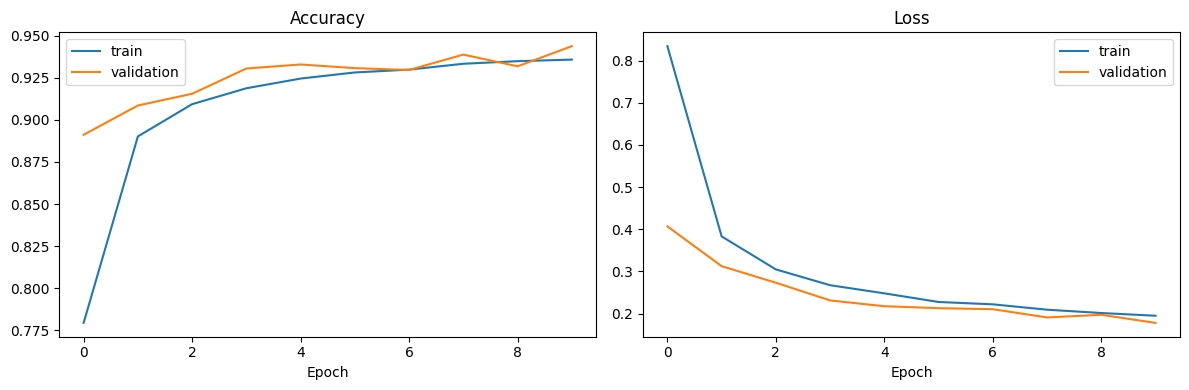

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

Running the model against the test set, images it has never seen in training or validation, to get an honest read on real performance.

In [8]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

145/145 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9477 - loss: 0.1675
Test accuracy: 94.77%
Test loss: 0.1675


A single accuracy number can hide a lot. Building a confusion matrix shows exactly which classes the model mixes up, which matters more for a diagnosis tool than an overall percentage.

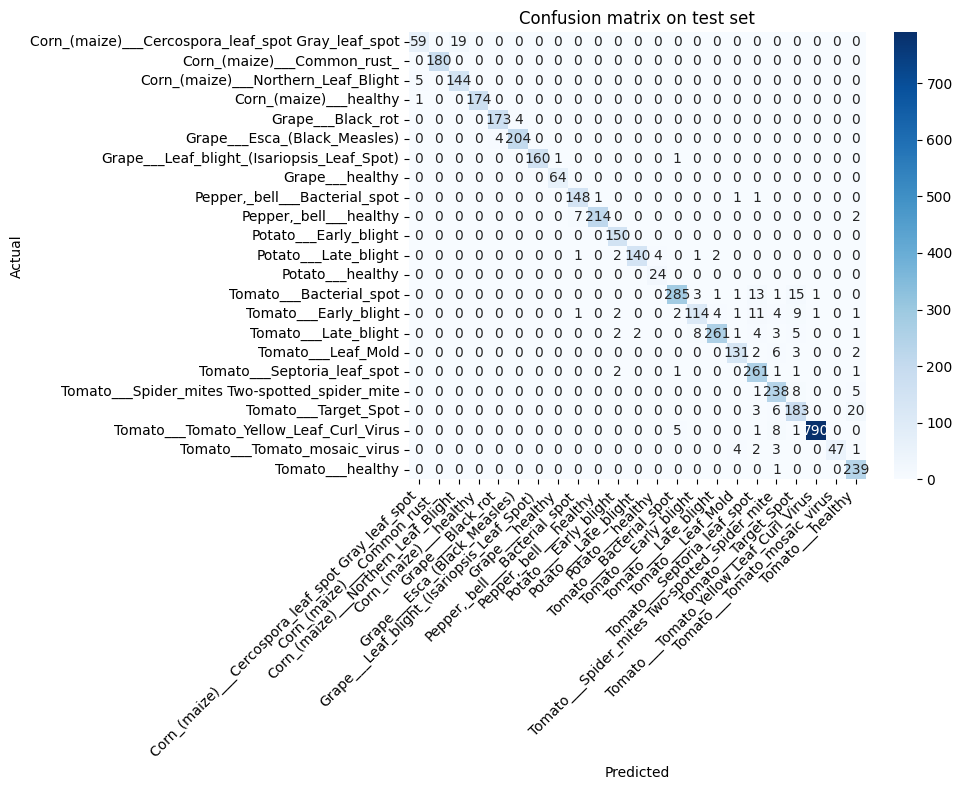

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.76      0.83        78
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       180
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.97      0.92       149
                            Corn_(maize)___healthy       1.00      0.99      1.00       175
                                 Grape___Black_rot       0.98      0.98      0.98       177
                      Grape___Esca_(Black_Measles)       0.98      0.98      0.98       208
        Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       1.00      0.99      0.99       162
                                   Grape___healthy       0.98      1.00      0.99        64
                     Pepper,_bell___Bacterial_spot       0.94      0.98      0.96       151
                            Pepper,_bell___healthy       1.00      0.96      0.

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix on test set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

Testing the model on a few individual images so I can see actual predictions next to actual photos, not just numbers in a table.

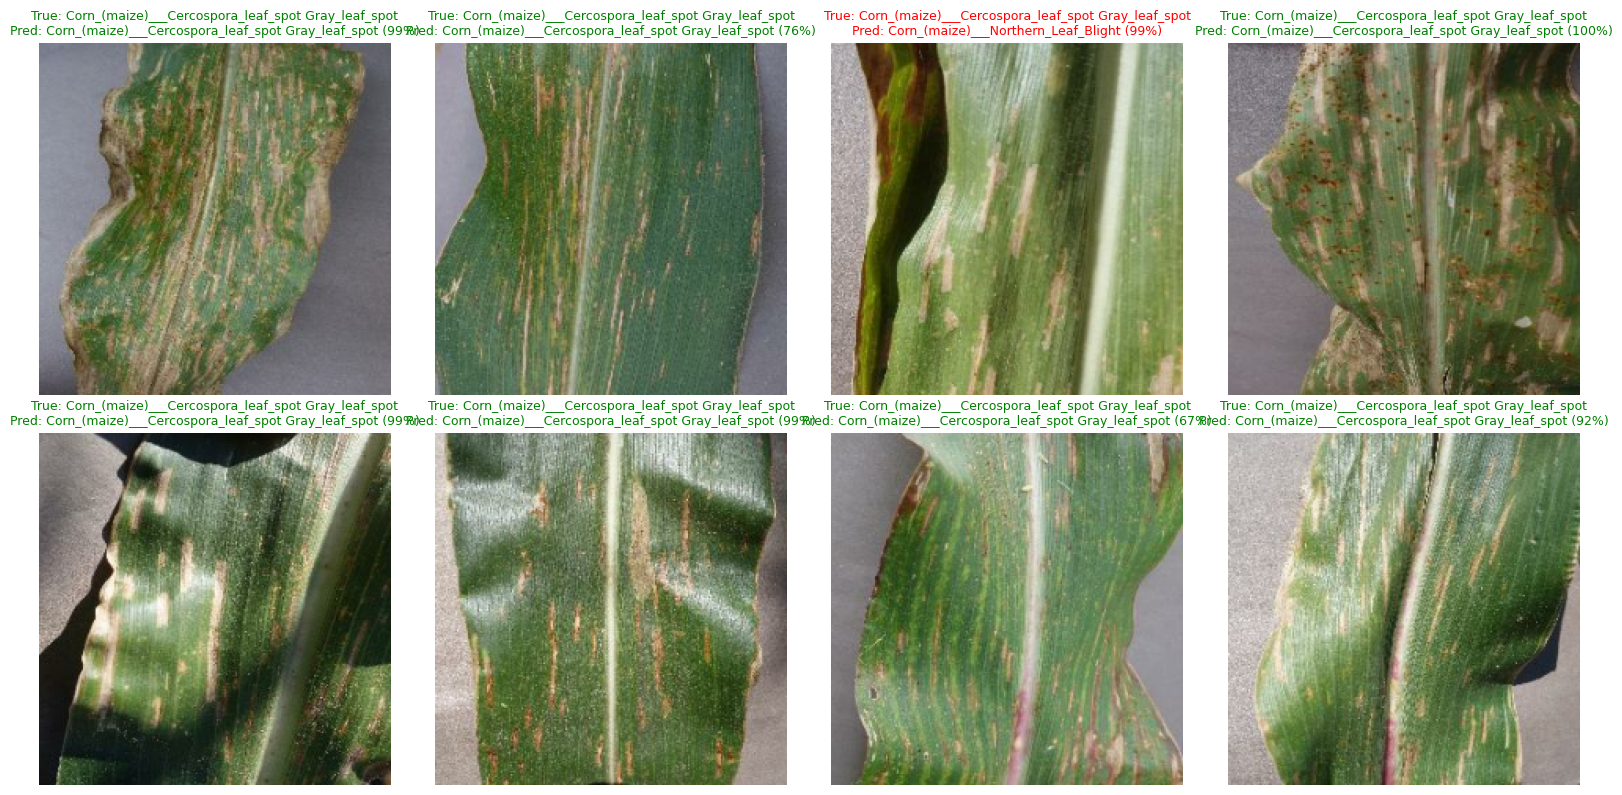

In [10]:
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(8):
        true_label = class_names[np.argmax(labels[i].numpy())]
        pred_label = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100

        axes[i].imshow(images[i].numpy().astype("uint8"))
        color = "green" if true_label == pred_label else "red"
        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
            fontsize=9, color=color
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
    break

Saving the trained model along with the class names, since I'll need both when wiring this into the WhatsApp bot. Keras saves to a single .h5 file, and I'm saving the class order separately as a small JSON file so the bot knows how to map predictions back to disease names.

In [11]:
import json
from google.colab import files

model.save("cropguard_model.h5")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved, downloading now")
files.download("cropguard_model.h5")
files.download("class_names.json")

Model and class names saved, downloading now


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model is trained, evaluated against a held out test set, and saved locally. The confusion matrix shows me exactly where it struggles, which is useful information going into the next stage, wiring this model into an actual WhatsApp bot so farmers can use it directly.
